<a href="https://colab.research.google.com/github/youraverax/QM2/blob/main/w01_python_recap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Recap

## *Workshop 1*  [![Open In Colab](https://github.com/oballinger/BASC0005/blob/main/colab-badge.png?raw=1)](https://colab.research.google.com/github/oballinger/BASC0005/blob/main/notebooks/W01.%20Python%20Recap.ipynb)

This workshop sets up the tools for the term and revisits the Python you covered in the prerequisites. If it is all familiar, go straight to the Kaggle exercises at the end.

### Aims

- Set up GitHub and save a copy of a Colab notebook to it
- Revisit variables, types, lists, dictionaries, loops, conditions and functions
- Understand how a notebook executes (and how running cells out of order can mislead you)
- Load a CSV from a URL with pandas, sort it and make a first plot
- Start checking whether the data *means* what it appears to mean

## Registering a GitHub account

GitHub is a platform for storing and sharing code with version control (Git). Think of it as Google Docs for code. You will use it for your group projects later in the term, and very likely in any future job involving data.

1. Use [this link](https://github.com/join) to register for a GitHub account if you do not already have one.
2. [Create a new repository](https://github.com/new) called "QM2".
3. In this notebook, click "File" and then "Save a copy in GitHub".

You now have a copy of this notebook in your own GitHub account. *Do step 3 for every workshop.*

## Using Python

We use *Python*, a programming language widely used in science, industry and on the web, to manipulate, plot and analyse data. This is a course about working with data rather than about programming, but we will learn some programming along the way.

A notebook mixes text cells (like this one) and code cells. Click on the cell below and press **Shift+Enter** to run it:

In [ ]:
print(4 + 4)

8


The notebook format lets you practise what Donald Knuth called [literate programming](https://en.wikipedia.org/wiki/Literate_programming): writing *documentation containing code* rather than code containing documentation. Use the text cells to explain what you are doing and why. Your future self, your group members and your markers will thank you.

## Libraries

*Libraries* (also called packages) add functions to Python. The main ones this term:

- **pandas**: tables of data ("dataframes"): loading, slicing, cleaning, summarising
- **matplotlib** and **seaborn**: plotting
- **geopandas**: maps and spatial data (Week 3)
- **spaCy**: working with text (Week 4)
- **statsmodels** and **scikit-learn**: statistics and machine learning (Weeks 5-10)

All of these come preinstalled on Colab. Let us revisit the basics first.

## Variables

Python code can be divided into *verbs* and *nouns*: things that **do** things (commands, functions, methods) and things that **are** things. The simplest noun is a **variable**: a name that stores a value. Values can be numbers, text or booleans (True/False):

In [ ]:
n = 1
t = "hi"
b = True

Every value has a **type**. `type()` tells you which one. Keep types in mind: next week we will see that many data problems are really *type* problems.

In [ ]:
print(n, type(n))
print(t, type(t))
print(b, type(b))
print(2.5, type(2.5))

1 <class 'int'>
hi <class 'str'>
True <class 'bool'>
2.5 <class 'float'>


## Where is my data?

In Excel you always see your data. In Python, variables live in the background, and you only see them when you ask. Check on them often, to make sure your code is doing what you think it is doing:

In [ ]:
n = n + 1
print(n)

2


## Flow

Python runs the commands in a cell from top to bottom. A notebook, however, lets you run cells in **any** order, and Python remembers the variables from every cell you have run, not just from the cells above.

In [ ]:
print(n)

2


In [ ]:
n = 3

Now go back and re-run the `print(n)` cell above. It prints 3, although the cell right above it says `n = n + 1`. Out-of-order execution is the most common source of "but it worked a minute ago" bugs. Before you submit anything, use **Runtime → Restart and run all** to check that the notebook works from top to bottom.

### Exercise: setting up variables

1. Create a variable `name` and assign your name to it.
2. Create a variable `python_score` with a score out of 10 for how much you like Python.
3. Create a variable `prior` that is `True` if you have used Python before and `False` otherwise.
4. Print all three, and print the type of each.

In [ ]:
# your code here

## Lists and dictionaries

A **list** is an ordered sequence of values, in square brackets:

In [ ]:
heights = [6, 5.5, 6, 5.5, 7.5]
print(heights)
print(heights[0])      # Python counts from 0
print(heights[-1])     # negative indices count from the end
print(len(heights))

[6, 5.5, 6, 5.5, 7.5]
6
7.5
5


A **dictionary** links **keys** to **values**, in curly brackets. You look values up by key, not by position:

In [ ]:
first_appearance = {"Bob": 1.2, "Mike": 1.2, "Coop": 1.1, "Maddy": 1.3, "Giant": 2.1}
print(first_appearance["Coop"])
print(first_appearance.keys())

1.1
dict_keys(['Bob', 'Mike', 'Coop', 'Maddy', 'Giant'])


### Exercise

Print (1) the third element of `heights`, and (2) the value in `first_appearance` for Giant. Then add a new entry for "Donna" with value 1.1.

In [ ]:
# your code here

## Loops, conditions and functions

A `for` loop repeats code for each item in a list; `if` runs code only when a condition is True:

In [ ]:
for name, episode in first_appearance.items():
    if episode >= 2:
        print(name, "first appears in season 2")
    else:
        print(name, "first appears in season 1")

Bob first appears in season 1
Mike first appears in season 1
Coop first appears in season 1
Maddy first appears in season 1
Giant first appears in season 2


A **function** packages code so that you can reuse it. `def` defines it and `return` sends the result back:

In [ ]:
def feet_to_metres(feet):
    return feet * 0.3048

print(feet_to_metres(6))
print([round(feet_to_metres(h), 2) for h in heights])   # a "list comprehension": a loop in one line

1.8288000000000002
[1.83, 1.68, 1.83, 1.68, 2.29]


### Exercise

Write a function `mean(values)` that returns the average of a list of numbers (hint: `sum()` and `len()`), and use it on `heights`. What happens if you call it on an empty list `[]`? What *should* happen?

In [ ]:
# your code here

## Dataframes with pandas

Real data is rarely a single list. **pandas** stores data in *dataframes*: tables with named columns and an index. We import it with the conventional short name `pd`.

`pd.read_csv` can read a file straight from a URL, so there is nothing to download. (On Colab you can also upload your own file: click the folder icon in the left sidebar, then the upload button.)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("https://s3.eu-west-2.amazonaws.com/qm2/wk1/data.csv")
data

,Name,First Appearance,Approx height,Gender,Law Enforcement
0,Bob,1.2,6.0,Male,False
1,Mike,1.2,5.5,Male,False
2,Coop,1.1,6.0,Male,True
3,Maddy,1.3,5.5,Female,False
4,Giant,2.1,7.5,Male,False
5,Donna,1.1,5.5,Female,False


`data.head()` shows the first five rows. `data.shape` gives (rows, columns), and `data.dtypes` gives the type pandas chose for each column:

In [ ]:
print(data.shape)
data.dtypes

(6, 5)


Name                    str
First Appearance    float64
Approx height       float64
Gender                  str
Law Enforcement        bool
dtype: object

A common first step is to **sort**. `sort_values` takes the column to sort by, and `ascending=False` sorts in descending order:

In [ ]:
data.sort_values(by="Approx height", ascending=False)

,Name,First Appearance,Approx height,Gender,Law Enforcement
4,Giant,2.1,7.5,Male,False
0,Bob,1.2,6.0,Male,False
2,Coop,1.1,6.0,Male,True
1,Mike,1.2,5.5,Male,False
3,Maddy,1.3,5.5,Female,False
5,Donna,1.1,5.5,Female,False


And a first plot. pandas dataframes have a `.plot()` method built on matplotlib:

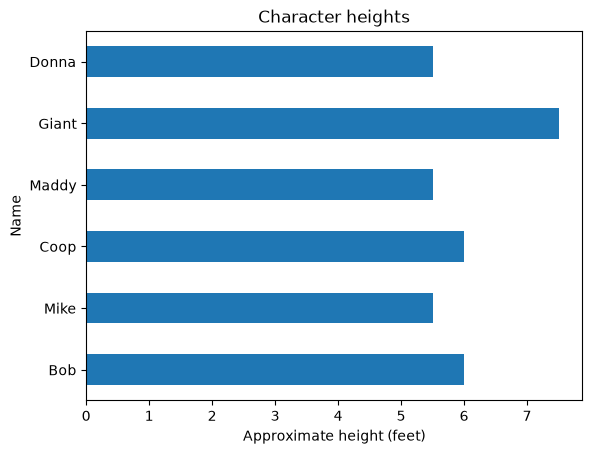

In [ ]:
data.plot.barh(x="Name", y="Approx height", legend=False)
plt.xlabel("Approximate height (feet)")
plt.title("Character heights")
plt.show()

### Exercise: spot the problem

`First Appearance` records the season and episode in which each character first appears: `1.2` means season 1, episode 2. pandas stored it as a `float64`.

1. What would happen to a character who first appears in season 1, episode **10**? (Try `float("1.10")`.)
2. Sort the dataframe by `First Appearance`. Would the order be right if the data contained episode 1.10?
3. How *should* this variable be stored? Write code that splits it into two integer columns, `season` and `episode`. (Hint: read the file again with `dtype={"First Appearance": str}`, then use `.str.split(".", expand=True)`.)

A number is only a number if arithmetic on it makes sense. Keep this in mind all term.

In [ ]:
# your code here

### Exercise: a second dataset

A second file, `https://s3.eu-west-2.amazonaws.com/qm2/wk1/sample_group.csv`, has scores for the same (and more) characters on three dimensions: `Context`, `Data` and `Design`.

1. Load it into a dataframe called `group` and look at it.
2. Which character has the highest `Data` score? (Use `sort_values`.) Are there ties?
3. Make a bar chart of the mean of each of the three columns (hint: `group[["Context", "Data", "Design"]].mean().plot(kind="bar")`), with a title and axis labels.

In [ ]:
# your code here

# Assessed Question

The URL below contains a dataset of the most streamed songs on Spotify in 2023:

https://oballinger.github.io/BASC0005/data/assessed/w01_spotify_2023.csv

Note that the file may have been corrupted over the years of running BASC0005; some column names might have been switched around, so make sure to sense-check your results.

**QUESTION: Among songs with more than 1 billion streams, how many streams does the most danceable one have?**

Keep a note of your answer: you will enter it in the Problem Set Answers quiz on Moodle in December.

In [ ]:
# Your code here


## Supplementary: Kaggle exercises

To practise further, work through the [Intro to Programming](https://www.kaggle.com/learn/intro-to-programming) and [Pandas](https://www.kaggle.com/learn/pandas) courses on Kaggle. They cover skills we use throughout the term.